In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
def tridag(a, b, c, r):
    """
    Function to solve a tri-diagonal system of equations
    a is lower diagonal, b is diagonal, c is upper diagonal, r is rhigh hand side
    tridag returns an array of size n containing the solution to the system of equations
    """

    n = len(r)
    res = np.empty(n)
    gam = np.empty(n)

    if b[0] == 0:
        raise RuntimeError("diagonal contains nil element in tridag")

    bet = b[0]
    res[0] = r[0] / bet
    for j in range(1, n):  # in Fortran the range is 2,n
        gam[j] = c[j - 1] / bet
        bet = b[j] - a[j] * gam[j]
        if bet == 0:
            raise RuntimeError("diagonal contains nil element in tridag")
        res[j] = (r[j] - a[j] * res[j - 1]) / bet

    for j in range(n - 2, -1, -1):  # in Fortran the range is n-1,1,-1
        res[j] = res[j] - gam[j + 1] * res[j + 1]

    return res

In [47]:
L = 1000 # in m
N = 101
dx = L/(N - 1)
K = 0.1 # in m^2/yr
dt = 10000 # in yrs

In [48]:
x = np.linspace(0,L,N)
h0 = 100*np.sin(2*np.pi*x/L)

In [49]:
F = K*dt/dx**2 # Courant number
print(F)
diag = np.repeat(1 + 2*F,N) # diagonal of tridiagonal matrix
upper = np.ones(N)*(-F) # upper diagonal
lower = np.ones_like(x)*(-F) # lower diagonal
diag[0] = 1 # boundary conditions at left (x=0) and right (x=L)
diag[-1] = 1
upper[0] = 0
lower[-1] = 0

10.0


In [50]:
h = tridag(lower, diag, upper, h0)

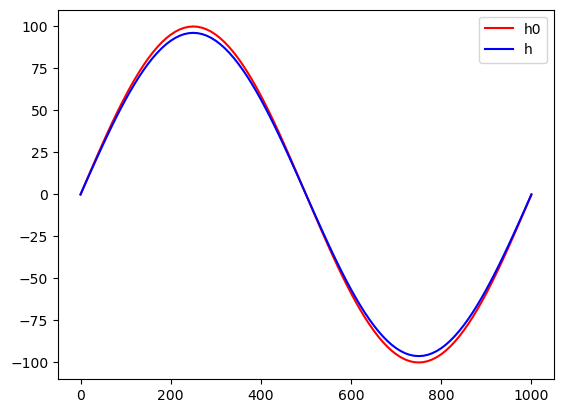

In [51]:
plt.plot(x,h0,c='red',label='h0')
plt.plot(x,h,c='blue', label='h')
plt.legend()

1.0


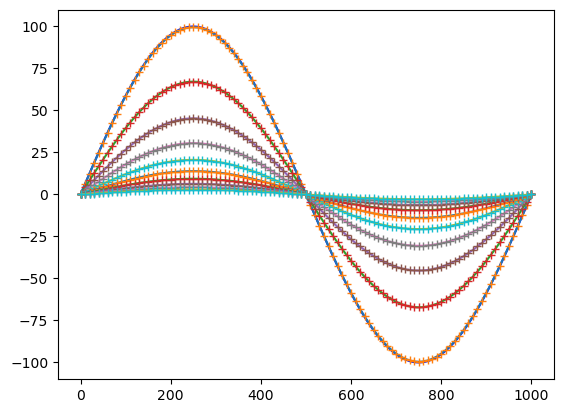

In [57]:
dt = 1000
F = K*dt/dx**2 # Courant number
diag = np.repeat(1 + 2*F,N) # diagonal of tridiagonal matrix
upper = np.ones(N)*(-F) # upper diagonal
lower = np.ones_like(x)*(-F) # lower diagonal
diag[0] = 1 # boundary conditions at left (x=0) and right (x=L)
diag[-1] = 1
upper[0] = 0
lower[-1] = 0

h = 100*np.sin(2*np.pi*x/L)
plt.plot(x,h,c='b')

for step in range(1000):
    t = (step + 1)*dt
    h = tridag(lower, diag, upper, h)
    ha = 100*np.sin(2*np.pi*x/L)*np.exp(-4*np.pi**2*K*t/L**2)
    if step%100==0:
        plt.plot(x,h)
        plt.plot(x,ha,'+')

print(F)